# The heat equation in two dimensions with Lagrange elements

We solve

$$u_t = \Delta u \quad \text{in } \Omega = (0, 1)^2, \qquad u = 0 \text{ on } \partial\Omega, \qquad u(x, y, 0) = u_0(x, y),$$

with the initial condition

$$u_0 = \sin \pi x \,\sin \pi y + \sin 3\pi x \,\sin 2\pi y.$$

Each of the two terms is an eigenfunction of $-\Delta$ with zero boundary values, with eigenvalue $2\pi^2$ and $13\pi^2$, so the exact solution is

$$u(x, y, t) = e^{-2\pi^2 t} \sin \pi x \,\sin \pi y + e^{-13\pi^2 t} \sin 3\pi x \,\sin 2\pi y.$$

The second term decays more than six times faster than the first, so the solution soon becomes a single bump.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import femd as fd
from femd import dot, grad, dx

**The mesh and the space.** A structured mesh of $20 \times 20$ squares, each cut into two triangles, and continuous piecewise quadratic ($P_2$) Lagrange elements. `bc="dirichlet"` builds $u = 0$ on the whole boundary into the space, so the boundary nodes are not unknowns.

In [2]:
m = fd.rectangle_mesh(0, 0, 1, 1, 20, 20)
V = fd.LagrangeSpace(m, 2, bc="dirichlet")
u, v = fd.TrialFunction(V), fd.TestFunction(V)
w = fd.Function(V)                                    # the solution
print(m.ntriangles, "triangles,", V.dim, "unknowns")

800 triangles, 1521 unknowns


## The semidiscretization

Multiplying the equation by a test function $v$ that vanishes on the boundary and integrating by parts gives the weak form

$$(u_t, v) + (\nabla u, \nabla v) = 0 \qquad \text{for every } v,$$

where $(f, g) = \int_\Omega f g\,dx\,dy$. The boundary term $\int_{\partial\Omega} v\,\partial_n u\,ds$ vanishes since $v = 0$ there. Writing the finite element solution as $u_h = \sum_k c_k(t) N_k(x, y)$ in the $P_2$ basis gives the system of ordinary differential equations

$$M c'(t) + K c(t) = 0, \qquad M_{ik} = (N_k, N_i), \qquad K_{ik} = (\nabla N_k, \nabla N_i),$$

with the mass matrix $M$ and the stiffness matrix $K$, both symmetric and positive definite.

**Backward Euler.** The system is stiff, so we use an implicit method. With the time step $\Delta t$ and $c^n \approx c(t_n)$,

$$M \frac{c^{n+1} - c^n}{\Delta t} + K c^{n+1} = 0, \qquad \text{that is} \qquad (M + \Delta t\, K)\, c^{n+1} = M c^n.$$

The matrix $M + \Delta t\, K$ is the same at every step, so we factor it once (a sparse Cholesky factorization) and each step is one product with $M$ and one solve.

In [3]:
dt = 0.001
M = fd.form(u * v * dx).assemble()
A = fd.form((u * v + dt * dot(grad(u), grad(v))) * dx).assemble()   # M + dt K
solver = A.solver()                                                 # factored once

x, y = fd.x, fd.y
u0 = fd.sin(np.pi * x) * fd.sin(np.pi * y) + fd.sin(3 * np.pi * x) * fd.sin(2 * np.pi * y)
w.project(u0)

Function('w', LagrangeSpace2D(degree=2, ncells=800, bc=Dirichlet on every exterior side, dim=1521))

**The time loop.** We go up to $t = 0.1$, keep the solution at a few times for the plots, and compute the $L^2$ error $\left\|u_h - u\right\|$ at every step from the exact solution, written as an expression in `fd.x` and `fd.y`.

In [4]:
T = 0.1
nsteps = round(T / dt)
keep = {0: w.vector.copy()}
times, errors = [], []
for n in range(1, nsteps + 1):
    solver.solve(M @ w.vector, into=w)                 # (M + dt K) c^{n+1} = M c^n
    t = n * dt
    exact = (np.exp(-2 * np.pi**2 * t) * fd.sin(np.pi * x) * fd.sin(np.pi * y)
             + np.exp(-13 * np.pi**2 * t) * fd.sin(3 * np.pi * x) * fd.sin(2 * np.pi * y))
    times.append(t)
    errors.append(np.sqrt(fd.form((w - exact)**2 * dx).assemble()))
    if n in (5, 20, 100):
        keep[n] = w.vector.copy()
print(f"L2 error at t = {T}: {errors[-1]:.2e}")

L2 error at t = 0.1: 1.35e-03


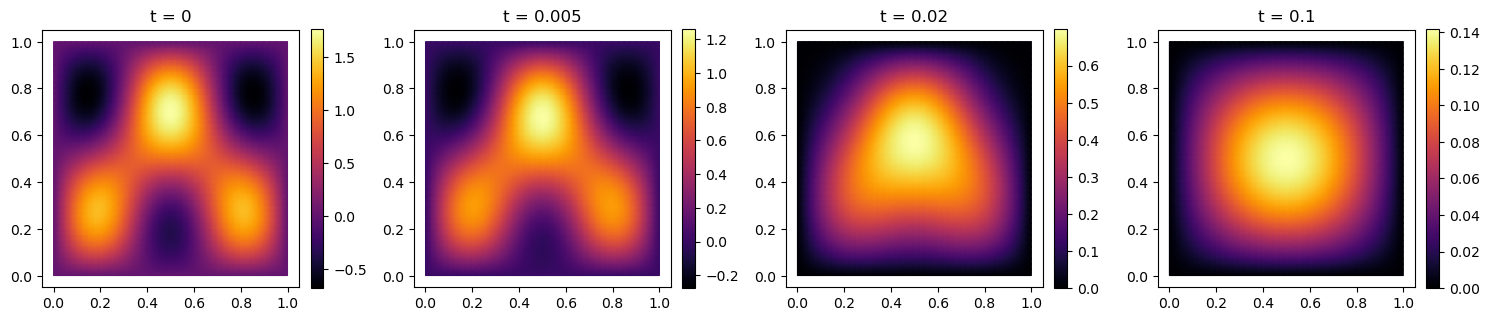

In [5]:
fig, axs = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, (n, coeffs) in zip(axs, keep.items()):
    fd.Function(V, "u", coeffs).plot(ax, cmap="inferno")
    ax.set_title(f"t = {n * dt:g}")
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

**Higher order in time.** Backward Euler is first order in $\Delta t$, and its error, about two per cent of the solution here, comes almost entirely from the time stepping. `fd.IRK` solves the same system $M c' = -K c$ with the two-stage Radau IIA method, which is of order 3 and also suited to stiff problems. The right-hand side is given as the form $-(\nabla w, \nabla v)$ in the solution $w$. With a ten times larger step it is almost a hundred times more accurate.

L2 error at t = 0.1: 1.53e-05


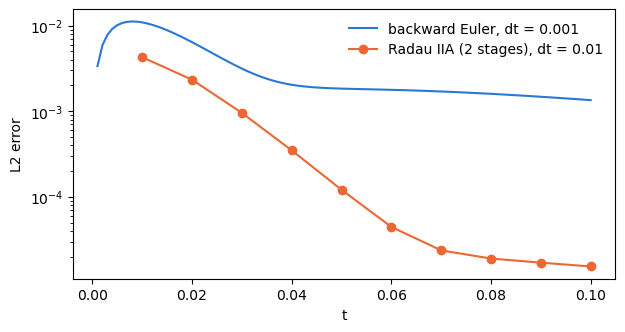

In [6]:
w2 = fd.Function(V)
w2.project(u0)
irk = fd.IRK(fd.form(u * v * dx), fd.form(-dot(grad(w2), grad(v)) * dx), 0.01, "radau", 2)
times2, errors2 = [], []
for n in range(1, 11):
    irk.step(w2)
    t = n * 0.01
    exact = (np.exp(-2 * np.pi**2 * t) * fd.sin(np.pi * x) * fd.sin(np.pi * y)
             + np.exp(-13 * np.pi**2 * t) * fd.sin(3 * np.pi * x) * fd.sin(2 * np.pi * y))
    times2.append(t)
    errors2.append(np.sqrt(fd.form((w2 - exact)**2 * dx).assemble()))
print(f"L2 error at t = {T}: {errors2[-1]:.2e}")

plt.figure(figsize=(7, 3.5))
plt.semilogy(times, errors, color="#2a78d6", label="backward Euler, dt = 0.001")
plt.semilogy(times2, errors2, "o-", color="#eb6834", label="Radau IIA (2 stages), dt = 0.01")
plt.xlabel("t"); plt.ylabel("L2 error"); plt.legend(frameon=False)
plt.show()